In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [157]:
df = pd.read_csv('iris.csv')
df

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


In [158]:
df.shape

(150, 5)

In [159]:
df.isna().sum()

sepal.length    0
sepal.width     0
petal.length    0
petal.width     0
variety         0
dtype: int64

In [160]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [161]:
df.describe()

,sepal.length,sepal.width,petal.length,petal.width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [162]:
df.head(1)

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa


In [163]:
df = df.rename(columns = {'sepal.length': 'sepal_length',
                    'sepal.width' : 'sepal_width',
                     'petal.length' : 'petal_length',
                     'petal.width' : 'petal_width'
                    }
         )

In [164]:
df

,sepal_length,sepal_width,petal_length,petal_width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


In [165]:
df.duplicated().sum()

1

In [166]:
df.drop_duplicates(inplace = True)

In [167]:
# Re-check
df.duplicated().sum()

0

# Visualization

In [168]:
df.variety.value_counts()

variety
Setosa        50
Versicolor    50
Virginica     49
Name: count, dtype: int64

C:\Users\Qbits\AppData\Local\Temp\ipykernel_17164\4056117620.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df.variety, palette='Set2')


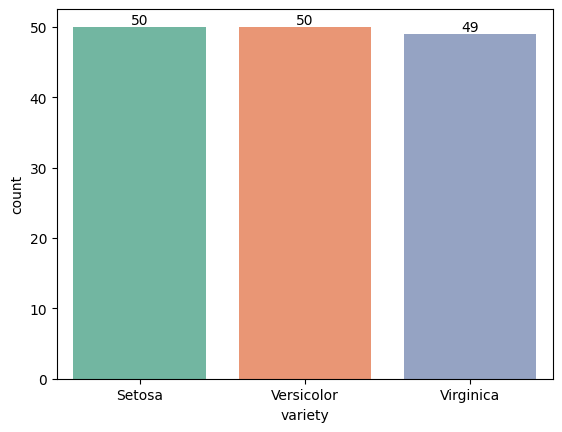

In [169]:

ax = sns.countplot(x=df.variety, palette='Set2')

for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                (bar.get_x() + bar.get_width() / 2, height),
                ha='center',
                va='bottom'
               )

plt.show()

## Distribution of Each Feature

array([[<Axes: title={'center': 'sepal_length'}>,
        <Axes: title={'center': 'sepal_width'}>],
       [<Axes: title={'center': 'petal_length'}>,
        <Axes: title={'center': 'petal_width'}>]], dtype=object)

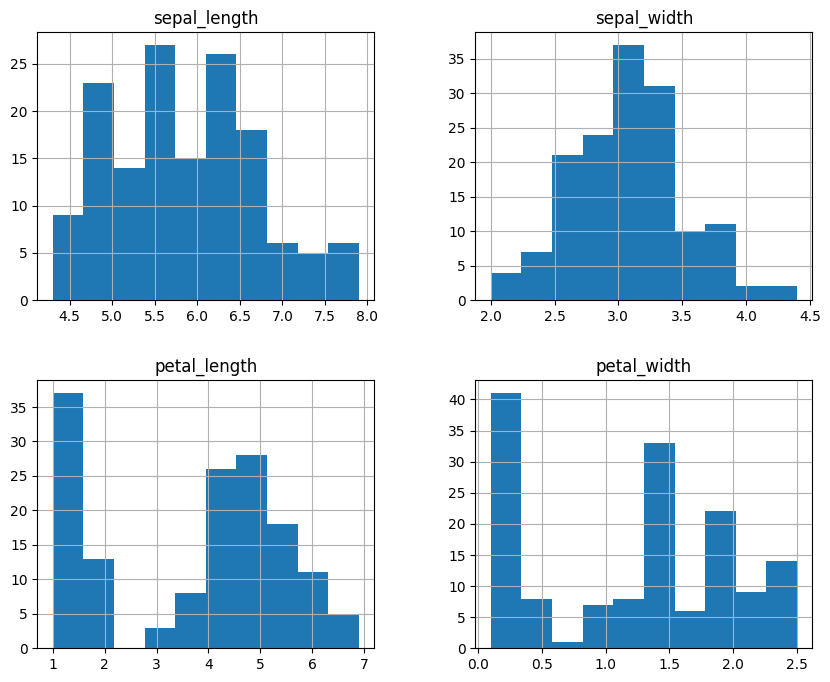

In [170]:
# Histogram
df.hist(figsize=(10, 8))

<Axes: ylabel='Density'>

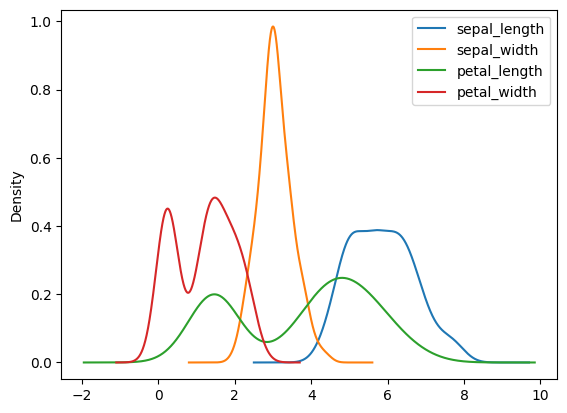

In [171]:
# KDE Plot
df.plot(kind='kde')

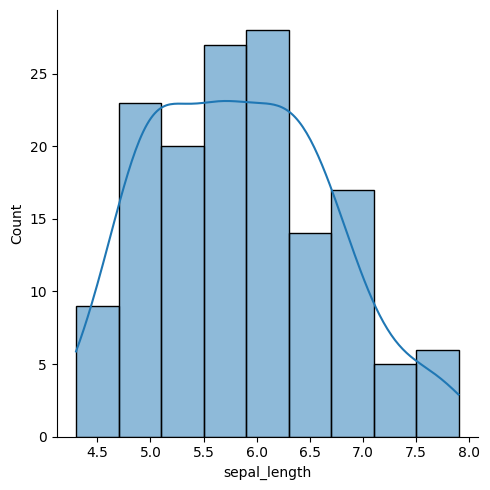

In [172]:
# Displot
sns.displot(df.sepal_length, kde=True)

##  Spread & Outlier Detection

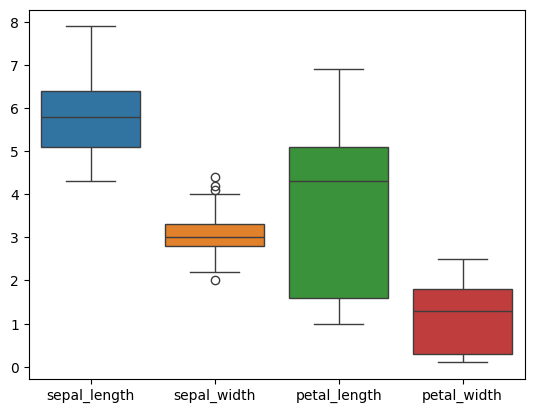

In [173]:
# Boxplot
sns.boxplot(data=df[['sepal_length','sepal_width','petal_length','petal_width']])
plt.show()

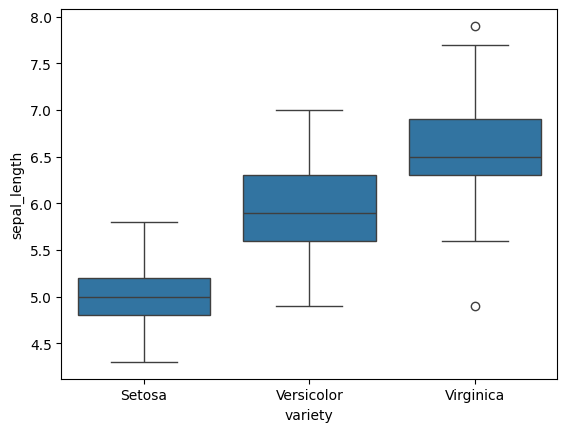

In [174]:
sns.boxplot(x=df.variety, y=df.sepal_length)
plt.show()

<Axes: >

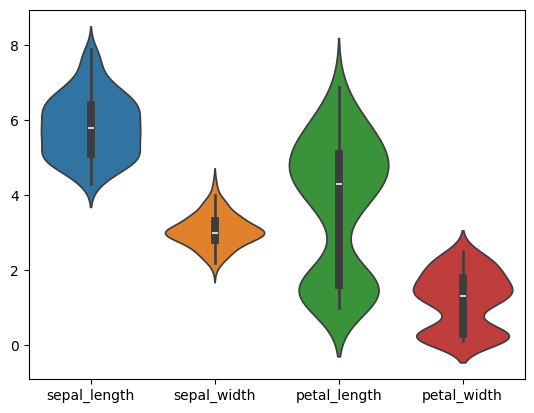

In [175]:
# Violinplot (boxplot + KDE)
sns.violinplot(data=df[['sepal_length','sepal_width','petal_length','petal_width']])

## Relationship Between Features

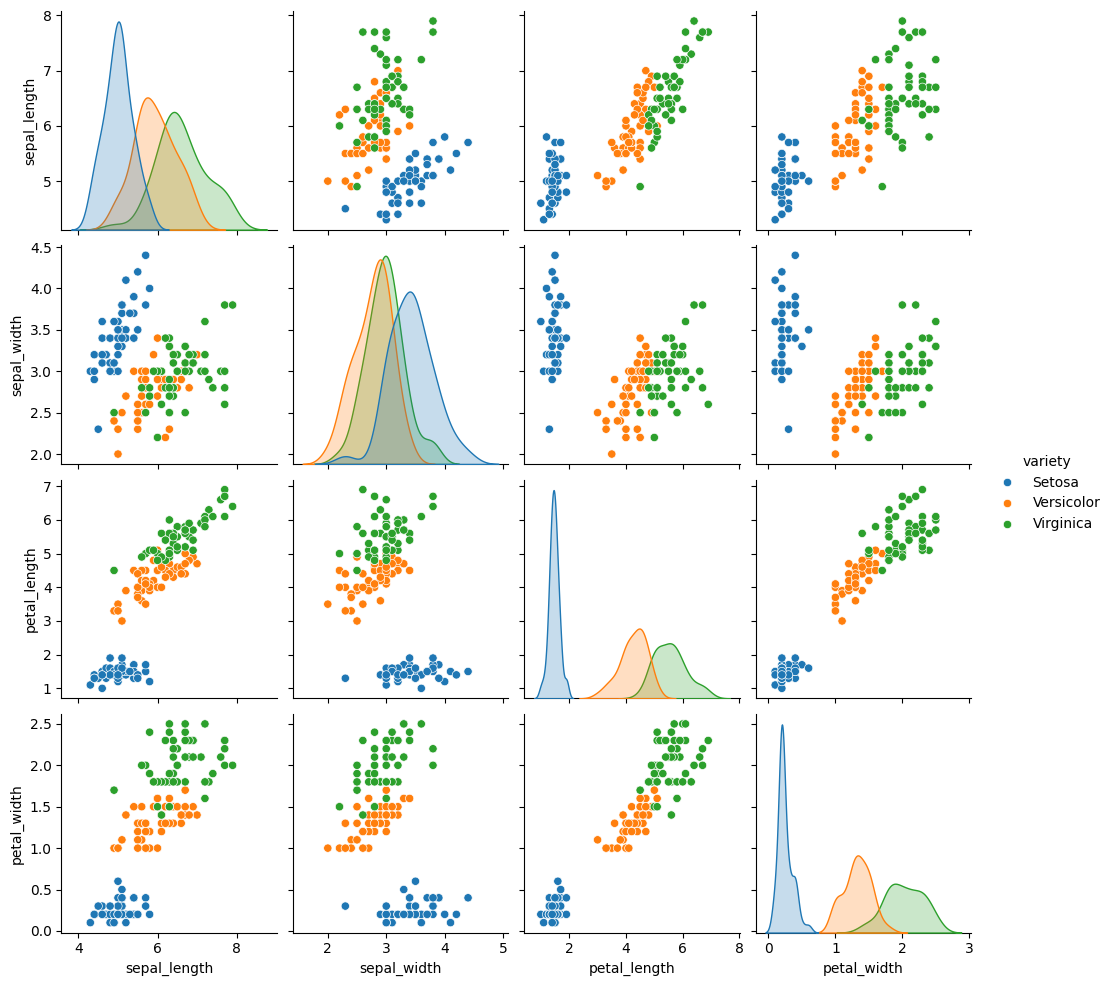

In [176]:
sns.pairplot(df, hue='variety')
plt.show()

<Axes: xlabel='sepal_length', ylabel='petal_length'>

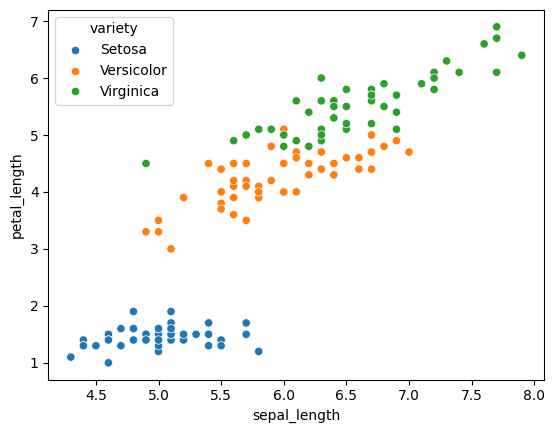

In [177]:
# Scatterplot
sns.scatterplot(x=df.sepal_length, y=df.petal_length, hue=df.variety)

## Grouped by Variety

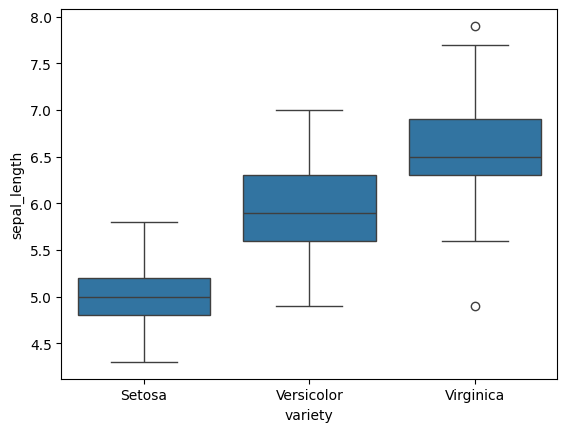

In [178]:
# Boxplot grouped
sns.boxplot(x=df.variety, y=df.sepal_length)
plt.show()

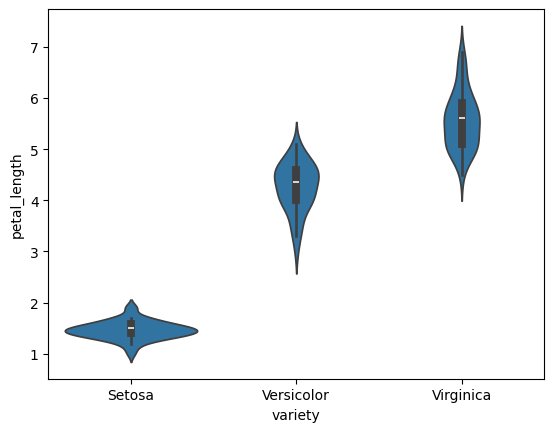

In [179]:
# Violinplot grouped
sns.violinplot(x=df.variety, y=df.petal_length)

plt.show()

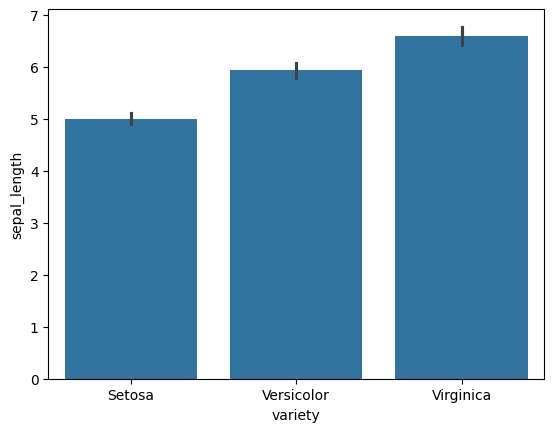

In [180]:
# Barplot (mean per group)
sns.barplot(x=df.variety, y=df.sepal_length)
plt.show()

##  Multivariate

<Axes: >

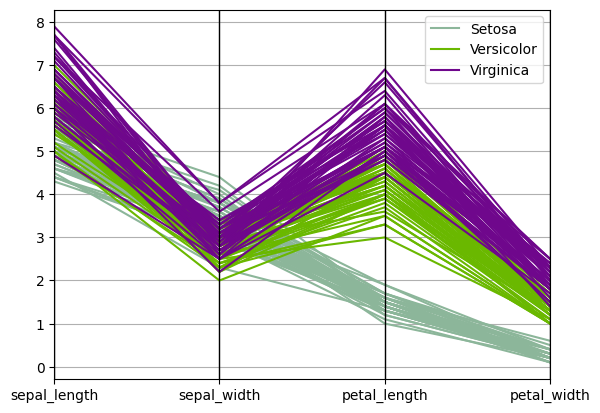

In [181]:
# Parallel coordinates
from pandas.plotting import parallel_coordinates
parallel_coordinates(df, 'variety')



<Axes: >

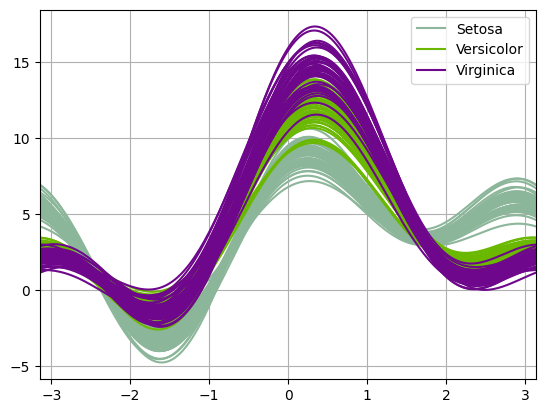

In [182]:
# Andrews curves
from pandas.plotting import andrews_curves
andrews_curves(df, 'variety')

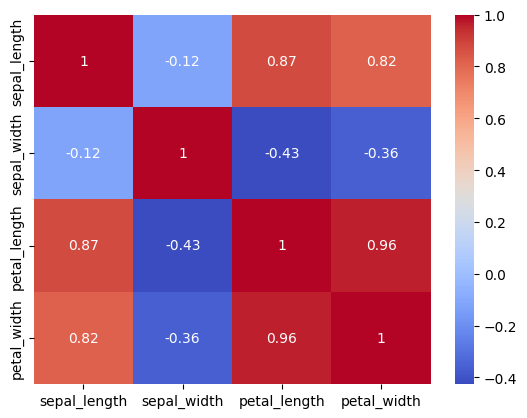

In [183]:
# Heatmap (correlation)
sns.heatmap(df.iloc[:, 0:4].corr(), annot=True, cmap='coolwarm')
plt.show()

# Dataset Split

In [184]:
x = df.drop('variety',axis = 1)
y = df['variety']

In [185]:
x.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [192]:
y.value_counts()

variety
Setosa        50
Versicolor    50
Virginica     49
Name: count, dtype: int64

## Feature Scaling

In [193]:
# Normalization (range 0 to 1)
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
x_scaled = mms.fit_transform(x)

In [196]:
x_scaled

array([[0.22222222, 0.625     , 0.06779661, 0.04166667],
       [0.16666667, 0.41666667, 0.06779661, 0.04166667],
       [0.11111111, 0.5       , 0.05084746, 0.04166667],
       [0.08333333, 0.45833333, 0.08474576, 0.04166667],
       [0.19444444, 0.66666667, 0.06779661, 0.04166667],
       [0.30555556, 0.79166667, 0.11864407, 0.125     ],
       [0.08333333, 0.58333333, 0.06779661, 0.08333333],
       [0.19444444, 0.58333333, 0.08474576, 0.04166667],
       [0.02777778, 0.375     , 0.06779661, 0.04166667],
       [0.16666667, 0.45833333, 0.08474576, 0.        ],
       [0.30555556, 0.70833333, 0.08474576, 0.04166667],
       [0.13888889, 0.58333333, 0.10169492, 0.04166667],
       [0.13888889, 0.41666667, 0.06779661, 0.        ],
       [0.        , 0.41666667, 0.01694915, 0.        ],
       [0.41666667, 0.83333333, 0.03389831, 0.04166667],
       [0.38888889, 1.        , 0.08474576, 0.125     ],
       [0.30555556, 0.79166667, 0.05084746, 0.125     ],
       [0.22222222, 0.625     ,

In [194]:
from sklearn.model_selection import train_test_split as tts
xtrain, xtest, ytrain, ytest = tts(x_scaled, y, test_size = 0.2, random_state = 42)

In [195]:
print(f'Shape of XTRAIN {xtrain.shape}')
print(f"Shape of YTRAIN: {ytrain.shape}")
print(f'Shape of XTEST: {xtest.shape}')
print(f'Shape of YTEST: {ytest.shape}')

Shape of XTRAIN (119, 4)
Shape of YTRAIN: (119,)
Shape of XTEST: (30, 4)
Shape of YTEST: (30,)


In [198]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(xtrain, ytrain)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [201]:
print(f'Train Score: {lr.score(xtrain, ytrain)}')
print(f'Test Score: {lr.score(xtest, ytest)}')

Train Score: 0.9327731092436975
Test Score: 0.9666666666666667


In [203]:
ypred = lr.predict(xtest)
ypred

array(['Versicolor', 'Setosa', 'Virginica', 'Versicolor', 'Versicolor',
       'Setosa', 'Versicolor', 'Virginica', 'Versicolor', 'Versicolor',
       'Virginica', 'Setosa', 'Setosa', 'Setosa', 'Setosa', 'Virginica',
       'Virginica', 'Versicolor', 'Versicolor', 'Virginica', 'Setosa',
       'Virginica', 'Setosa', 'Virginica', 'Virginica', 'Virginica',
       'Virginica', 'Virginica', 'Setosa', 'Setosa'], dtype=object)

In [204]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
print(f'Accuracy Score: {accuracy_score(ytest, ypred)}')

Accuracy Score: 0.9666666666666667


In [205]:
print(f'Classification Report: \n{classification_report(ytest,ypred)}')

Classification Report: 
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      0.89      0.94         9
   Virginica       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



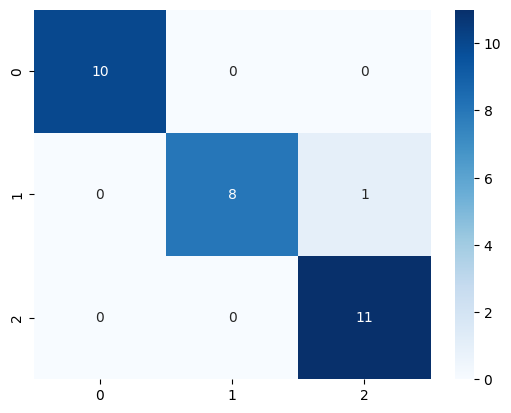

In [206]:
cm = confusion_matrix(ytest,ypred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()